In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.stats import linregress
import seaborn as sns

In [2]:
pd.options.display.max_columns = None

In [3]:
df = pd.read_csv('../data/nova_pay_combined.csv')

In [4]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [5]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [6]:
df["datetime"] = pd.to_datetime(df.timestamp, errors = "coerce")

In [10]:
pd.merge(
    df.loc[:, [
        "customer_id", "datetime", "amount_usd",
        "fee", "ip_address", "ip_country",
        "kyc_tier", "device_trust_score"
    ]].isnull().sum().rename("all").to_frame(),
    df.loc[df.ip_address.isnull(),
           [
               "customer_id", "datetime", "amount_usd", "fee",
               "ip_address", "ip_country", "kyc_tier", "device_trust_score"
           ]].isnull().sum().rename("null_ip").to_frame(),
    how = "inner", left_index = True, right_index = True

)

,all,null_ip
customer_id,0,0
datetime,61,0
amount_usd,305,305
fee,295,295
ip_address,305,305
ip_country,301,301
kyc_tier,300,300
device_trust_score,295,295


In [47]:
df.loc[df.ip_address.isnull(), "is_fraud"].value_counts(normalize = True).round(3) * 100

is_fraud
0    97.4
1     2.6
Name: proportion, dtype: float64

In [23]:
df.loc[(df.ip_address.isnull()) & (df.ip_country.notnull()), "ip_country"]

364         NAN
3185    unknown
4415      nan  
7821        NAN
Name: ip_country, dtype: str

In [25]:
df.loc[(df.ip_address.isnull()) & (df.kyc_tier.notnull()), "kyc_tier"]

364         NAN
3185    unknown
4415    unknown
7821      nan  
8494      nan  
Name: kyc_tier, dtype: str

In [26]:
df.loc[(df.ip_address.isnull()) & (df.device_trust_score.notnull()), "device_trust_score"]

1246   -0.1
1311   -0.1
1677   -0.1
2486   -0.1
3088   -0.1
4589   -0.1
5469   -0.1
5521   -0.1
6045   -0.1
8001   -0.1
Name: device_trust_score, dtype: float64

In [40]:
df.loc[df.device_trust_score < 0, "device_trust_score"].shape

(204,)

In [42]:
df.device_trust_score.value_counts(normalize = True).sort_index()

device_trust_score
-0.100    0.01837
 0.005    0.00009
 0.011    0.00009
 0.014    0.00009
 0.015    0.00018
           ...   
 0.972    0.00009
 0.976    0.00018
 0.980    0.00009
 0.988    0.00009
 0.999    0.00009
Name: proportion, Length: 677, dtype: float64

In [29]:
df.loc[df.ip_address.isnull(), "txn_velocity_1h"].value_counts()

txn_velocity_1h
 0    289
-1     10
 7      2
 4      2
 5      1
 6      1
Name: count, dtype: int64

In [30]:
df.loc[df.ip_address.isnull(), "txn_velocity_24h"].value_counts()

txn_velocity_24h
0    276
1     22
7      2
4      2
5      1
6      1
2      1
Name: count, dtype: int64

In [36]:
df.loc[df.txn_velocity_1h < 0, "txn_velocity_24h"].value_counts()

txn_velocity_24h
0    186
1     15
3      1
6      1
2      1
Name: count, dtype: int64

In [37]:
df.loc[df.txn_velocity_1h == 1, "txn_velocity_24h"].value_counts()

txn_velocity_24h
1    69
2    36
3    30
Name: count, dtype: int64

In [27]:
df.loc[(df.ip_address.isnull()) & (df.fee.notnull()), "fee"]

1246      -1.00
1311    9999.99
1677      -1.00
2486      -1.00
3088      -1.00
4589    9999.99
5469      -1.00
5521      -1.00
6045    9999.99
8001      -1.00
Name: fee, dtype: float64

In [44]:
df.loc[df.fee < df.fee.max(), "fee"].max()

np.float64(179.74)

In [46]:
df.loc[df.fee == df.fee.max(), "fee"].value_counts()

fee
9999.99    103
Name: count, dtype: int64

In [13]:
df.is_fraud.value_counts(normalize = True).round(3) * 100

is_fraud
0    91.3
1     8.7
Name: proportion, dtype: float64

In [14]:
df.loc[df.ip_address.isnull(), "is_fraud"].value_counts(normalize = True).round(3) * 100

is_fraud
0    97.4
1     2.6
Name: proportion, dtype: float64

In [16]:
df.loc[df.ip_address.isnull(), "new_device"].value_counts(normalize = True).round(3) * 100

new_device
False    90.5
True      9.5
Name: proportion, dtype: float64

In [17]:
df.loc[df.ip_address.isnull(), "location_mismatch"].value_counts(normalize = True).round(3) * 100

location_mismatch
False    89.5
True     10.5
Name: proportion, dtype: float64

In [18]:
df.home_country.unique()

<StringArray>
['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  ']
Length: 7, dtype: str

In [21]:
df.ip_country.value_counts(normalize = True).round(3) * 100

ip_country
US         61.7
UK         21.7
CA         15.6
 US         0.4
unknown     0.3
 UK         0.2
 CA         0.1
NAN         0.0
 nan        0.0
Name: proportion, dtype: float64

In [20]:
df.loc[df.ip_address.isnull(), "ip_country"].value_counts(normalize = True).round(3) * 100

ip_country
NAN        50.0
unknown    25.0
 nan       25.0
Name: proportion, dtype: float64

In [49]:
df.home_country.str.strip().value_counts()

home_country
US         8008
UK         2132
CA         1228
unknown      32
Name: count, dtype: int64

In [50]:
df.home_country = df.home_country.str.strip()

In [51]:
df.home_country.value_counts()

home_country
US         8008
UK         2132
CA         1228
unknown      32
Name: count, dtype: int64

In [52]:
customers_home_country = df.groupby(by = ["customer_id"]).aggregate({"home_country": pd.Series.nunique})
customers_home_country

,home_country
customer_id,
0006f893-10a8-4235-831b-fcae1e3f0140,1
00147b79-11ed-4f8f-a3af-651778b78dd3,1
00668d83-6f9f-4401-9a0f-04f94140abb6,1
00957a15-945f-4bfb-b5fc-d867cbaee95d,1
00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1
...,...
feabfbce-0104-4f21-ba98-991e86b21774,1
feec7b74-5e30-4ac2-9aca-b7724f6fc179,1
ff82d8ff-a00f-4be3-b7a7-4adae615e36c,1


In [53]:
customers_home_country.home_country.unique()

array([1, 2])

In [54]:
customers_home_country.loc[customers_home_country.home_country > 1]

,home_country
customer_id,
23d9943d-57b1-42eb-9ef2-05eed7fd1957,2
402cccc9-28de-45b3-9af7-cc5302aa1f93,2
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2
70a93d26-8e3a-4179-900c-a4a7a74d08e5,2
7bd5200c-5d19-44f0-9afe-8b339a05366b,2
7e5600c3-9d8b-488d-b761-5b530fa49f27,2
af8ca4c4-8703-4c55-b66c-2b76cd70040d,2


In [55]:
customers = customers_home_country.loc[customers_home_country.home_country > 1].index.tolist()

In [56]:
df.loc[df.customer_id.isin(customers)].groupby(by = ["customer_id"]).aggregate({"home_country":pd.Series.unique})

,home_country
customer_id,
23d9943d-57b1-42eb-9ef2-05eed7fd1957,"[UK, unknown]"
402cccc9-28de-45b3-9af7-cc5302aa1f93,"[US, unknown]"
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,"[CA, unknown]"
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,"[US, unknown]"
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,"[UK, unknown]"
70a93d26-8e3a-4179-900c-a4a7a74d08e5,"[US, unknown]"
7bd5200c-5d19-44f0-9afe-8b339a05366b,"[US, unknown]"
7e5600c3-9d8b-488d-b761-5b530fa49f27,"[US, unknown]"
af8ca4c4-8703-4c55-b66c-2b76cd70040d,"[US, unknown]"


In [57]:
home_country = df.loc[df.customer_id.isin(customers)].groupby(by = ["customer_id"]).aggregate({"home_country":pd.Series.unique}).home_country.apply(lambda x: x[0]).to_dict()
home_country

{'23d9943d-57b1-42eb-9ef2-05eed7fd1957': 'UK',
 '402cccc9-28de-45b3-9af7-cc5302aa1f93': 'US',
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad': 'CA',
 '6d0d9b27-fa26-45f8-93b1-2df29d182d9c': 'US',
 '7041b9c1-3719-4ca8-9a6b-811b47cea6c0': 'UK',
 '70a93d26-8e3a-4179-900c-a4a7a74d08e5': 'US',
 '7bd5200c-5d19-44f0-9afe-8b339a05366b': 'US',
 '7e5600c3-9d8b-488d-b761-5b530fa49f27': 'US',
 'af8ca4c4-8703-4c55-b66c-2b76cd70040d': 'US',
 'd71c91b4-fee8-4104-9856-a5c6109a62e3': 'US',
 'f7531a78-8bbe-4a85-b1e8-a0650edddc72': 'US'}

In [58]:
df.loc[(df.customer_id.isin(customers)) & (df.home_country == "unknown"), "home_country"] = df.loc[(df.customer_id.isin(customers)) & (df.home_country == "unknown"), ["customer_id", "home_country"]].apply(lambda x: home_country.get(x.customer_id), axis = 1)

In [59]:
df.home_country.value_counts()

home_country
US    8031
UK    2139
CA    1230
Name: count, dtype: int64

In [61]:
df.ip_country.unique()

<StringArray>
['US', 'CA', nan, 'UK', ' US  ', 'NAN', 'unknown', ' CA  ', ' UK  ', ' nan  ']
Length: 10, dtype: str

In [62]:
df.ip_country = df.ip_country.str.strip().apply(lambda x: np.nan if x in ["NAN", "nan"] else x)

In [63]:
df.ip_country.value_counts()

ip_country
US         6897
UK         2425
CA         1741
unknown      33
Name: count, dtype: int64

In [65]:
df.loc[
    (df.ip_country.notnull()) &
    (df.home_country != df.ip_country),
    "location_mismatch"
].mean()

np.float64(0.9830693610049154)

In [66]:
df.loc[
    (df.ip_country.notnull()) &
    (df.home_country == df.ip_country) &
    (df.location_mismatch),
    ["customer_id", "datetime", "home_country", "ip_country", "location_mismatch"]
]

,customer_id,datetime,home_country,ip_country,location_mismatch
10254,d741ff3a-5bf0-45da-b6a6-8bca86774141,2024-01-05 09:42:49.573611+00:00,CA,CA,True
10272,a4e38294-55f1-443a-9a89-9ff2a2952c47,2024-01-15 10:14:32.573611+00:00,US,US,True
10390,87a3670e-dc21-4366-acdf-fb40c2e649ab,2024-04-14 09:20:21.573611+00:00,US,US,True
10458,dc1ec03d-b327-43af-82bd-2461ea087936,2024-05-18 09:10:31.573611+00:00,US,US,True
10466,80b7a4b7-4ab0-4101-9dd4-ea8f6e42571f,2024-05-21 11:42:49.573611+00:00,UK,UK,True
10473,0e1720d3-173a-4ca7-a889-28289c0e1a26,2024-05-28 17:02:22.573611+00:00,US,US,True
10586,290f0121-9e7d-4953-aaad-fbb024ac749c,2024-08-08 16:25:30.573611+00:00,US,US,True
10627,5edff35f-c02b-4e1c-9c0f-58dd65613368,2024-09-04 12:32:43.573611+00:00,US,US,True
10700,3ca06712-688e-453d-ae03-032fdd1771b4,2024-10-07 10:39:57.573611+00:00,UK,UK,True
10728,a2c0e41c-7886-4193-98b2-04790a6f7495,2024-10-24 14:57:03.573611+00:00,US,US,True


In [67]:
customers = df.loc[
    (df.ip_country.notnull()) &
    (df.home_country == df.ip_country) &
    (df.location_mismatch),
    "customer_id"
].tolist()

In [68]:
df.loc[df.customer_id.isin(customers), "customer_id"].value_counts()

customer_id
d741ff3a-5bf0-45da-b6a6-8bca86774141    1
a4e38294-55f1-443a-9a89-9ff2a2952c47    1
87a3670e-dc21-4366-acdf-fb40c2e649ab    1
dc1ec03d-b327-43af-82bd-2461ea087936    1
80b7a4b7-4ab0-4101-9dd4-ea8f6e42571f    1
0e1720d3-173a-4ca7-a889-28289c0e1a26    1
290f0121-9e7d-4953-aaad-fbb024ac749c    1
5edff35f-c02b-4e1c-9c0f-58dd65613368    1
3ca06712-688e-453d-ae03-032fdd1771b4    1
a2c0e41c-7886-4193-98b2-04790a6f7495    1
f175f7de-153c-4f6b-82a5-84f7fc865fef    1
e7333eb0-38e5-47fa-a108-9d90b351a093    1
3460e415-fbac-4b12-b694-bfd9d8892d26    1
9fb6f540-2b58-4377-b2ac-ee1a8800f721    1
5d1f9bb6-b9dd-4ec0-ac96-f1439bdb76a3    1
462848c6-8102-4179-8332-879a6ece388a    1
1e5e4b4d-a168-48f9-8243-a57422dae0b0    1
a1d6add2-f3f9-4286-8eca-60b3f05fc916    1
c5600ee4-32a9-4689-8a6a-86e5946616a8    1
14b0135b-714f-4b2d-9ca1-23760c535558    1
Name: count, dtype: int64

In [69]:
df.loc[(df.ip_country.notnull()) & (df.home_country == df.ip_country) & (df.location_mismatch), "location_mismatch"] = False

In [73]:
df.loc[
    (df.ip_country.notnull()) &
    (df.home_country != df.ip_country) &
    (~df.location_mismatch),
    ["customer_id", "datetime", "home_country", "ip_country", "location_mismatch"]
]

,customer_id,datetime,home_country,ip_country,location_mismatch
712,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-12-23 10:09:56.468549+00:00,UK,unknown,False
933,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-01-16 13:46:08.468549+00:00,US,unknown,False
1232,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-02-14 22:28:21.468549+00:00,US,unknown,False
1290,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-02-22 05:17:57.468549+00:00,US,unknown,False
1623,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-04-01 12:50:20.468549+00:00,US,unknown,False
2145,d71c91b4-fee8-4104-9856-a5c6109a62e3,2023-05-30 07:25:30.468549+00:00,US,unknown,False
2313,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2023-06-18 06:22:18.468549+00:00,US,unknown,False
2572,d71c91b4-fee8-4104-9856-a5c6109a62e3,2023-07-14 03:58:42.468549+00:00,US,unknown,False
3172,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-09-21 22:04:58.468549+00:00,UK,unknown,False
3185,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2023-09-23 19:03:22.468549+00:00,US,unknown,False


In [74]:
df.loc[(df.ip_country.notnull()) & (df.home_country != df.ip_country) & (~df.location_mismatch), "ip_country"] = df.loc[(df.ip_country.notnull()) & (df.home_country != df.ip_country) & (~df.location_mismatch), "home_country"]

In [75]:
df.ip_country.value_counts()

ip_country
US         6921
UK         2431
CA         1742
unknown       2
Name: count, dtype: int64

In [77]:
df.ip_country.isnull().sum()

np.int64(304)

In [58]:
df.loc[df.ip_country == "unknown", ["customer_id", "datetime", "home_country", "ip_address", "ip_country", "location_mismatch", "is_fraud"]]

,customer_id,datetime,home_country,ip_address,ip_country,location_mismatch,is_fraud
8529,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2025-04-28 14:44:40.468549+00:00,CA,7.187.51.25,unknown,True,0
9140,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-07-02 21:57:48.468549+00:00,US,99.148.50.57,unknown,True,0


In [79]:
df.loc[(df.ip_country.isnull()) & (~df.location_mismatch), ["ip_country", "home_country", "location_mismatch"]]

,ip_country,home_country,location_mismatch
13,NaN,UK,False
49,NaN,US,False
151,NaN,US,False
163,NaN,CA,False
180,NaN,US,False
...,...,...,...
10054,NaN,US,False
10082,NaN,US,False
10093,NaN,US,False
10142,NaN,UK,False


In [81]:
df.loc[(df.ip_country.isnull()) & (~df.location_mismatch), "ip_country"] = df.loc[(df.ip_country.isnull()) & (~df.location_mismatch), "home_country"]

In [82]:
df.ip_country.isnull().sum()

np.int64(32)

In [84]:
df.loc[df.ip_country.isnull(), ["ip_country", "home_country", "location_mismatch", "ip_address"]]

,ip_country,home_country,location_mismatch,ip_address
168,NaN,US,True,NaN
364,NaN,US,True,NaN
475,NaN,US,True,NaN
867,NaN,US,True,NaN
1311,NaN,US,True,NaN
1560,NaN,CA,True,NaN
1822,NaN,US,True,NaN
1998,NaN,US,True,NaN
2580,NaN,US,True,NaN
3081,NaN,UK,True,NaN


In [86]:
df.loc[df.ip_country.isnull(), "ip_country"] = "unknown"

In [87]:
df.ip_country.isnull().sum()

np.int64(0)

In [89]:
df.ip_country.value_counts(normalize = True).round(4) * 100

ip_country
US         62.37
UK         21.86
CA         15.47
unknown     0.30
Name: proportion, dtype: float64

In [90]:
df.kyc_tier.unique()

<StringArray>
[   'standard',    'enhanced',         'low', ' standard  ',           nan,
     'standrd', ' enhanced  ',    'STANDARD',         'NAN',     'unknown',
     'enhancd',      ' low  ',    'ENHANCED',         'LOW',      ' nan  ']
Length: 15, dtype: str

In [91]:
df.kyc_tier.isnull().sum()

np.int64(300)

In [92]:
df.kyc_tier = df.kyc_tier.str.strip().str.lower().str.replace({"standrd": "standard", "enhancd": "enhanced"}).replace({"nan": np.nan})

In [93]:
df.kyc_tier.isnull().sum()

np.int64(303)

In [97]:
customer_kyc = df.groupby(by = ["customer_id"]).aggregate({"kyc_tier": "nunique"})
customer_kyc.head()

,kyc_tier
customer_id,
0006f893-10a8-4235-831b-fcae1e3f0140,1
00147b79-11ed-4f8f-a3af-651778b78dd3,1
00668d83-6f9f-4401-9a0f-04f94140abb6,1
00957a15-945f-4bfb-b5fc-d867cbaee95d,1
00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1


In [98]:
customer_kyc.kyc_tier.unique()

array([1, 2, 0])

In [99]:
customer_kyc.loc[customer_kyc.kyc_tier == 0]

,kyc_tier
customer_id,
691bb730-3142-40b3-a64f-0e54dc199252,0


In [100]:
df.loc[df.customer_id == "691bb730-3142-40b3-a64f-0e54dc199252"]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
536,46c8d157-c4fc-40f1-88a9-5039119f8d2e,691bb730-3142-40b3-a64f-0e54dc199252,2022-12-05 00:45:02.468549+00:00,UK,GBP,CNY,web,280.18,NaN,NaN,8.928571,9593519b-5581-40a2-a502-f17e3d790671,False,NaN,UK,False,0.342,NaN,208,NaN,0,0.294,0,0,0.0,0,2022-12-05 00:45:02.468549+00:00
4200,da3163c2-2f33-47e5-a721-9097791cbc11,691bb730-3142-40b3-a64f-0e54dc199252,2024-01-09 03:16:26.468549+00:00,UK,GBP,CAD,mobile,102.1,NaN,NaN,1.689189,9593519b-5581-40a2-a502-f17e3d790671,False,NaN,UK,False,0.206,NaN,208,NaN,0,0.294,0,0,0.0,0,2024-01-09 03:16:26.468549+00:00


In [103]:
customers = customer_kyc.loc[customer_kyc.kyc_tier > 1].index.tolist()

In [104]:
df.loc[df.customer_id.isin(customers)].groupby(by = ["customer_id"]).aggregate({"kyc_tier":"unique"})

,kyc_tier
customer_id,
23d9943d-57b1-42eb-9ef2-05eed7fd1957,"[standard, nan, unknown]"
402cccc9-28de-45b3-9af7-cc5302aa1f93,"[standard, nan, unknown]"
4fa7972c-e13c-4c84-a509-332fc7da9575,"[standard, unknown]"
66c71a44-d07c-4a20-a576-0a377193bf6b,"[standard, nan, unknown]"
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,"[enhanced, nan, unknown]"
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,"[nan, standard, unknown]"
70a93d26-8e3a-4179-900c-a4a7a74d08e5,"[enhanced, nan, unknown]"
7bd5200c-5d19-44f0-9afe-8b339a05366b,"[standard, nan, unknown]"
af8ca4c4-8703-4c55-b66c-2b76cd70040d,"[standard, nan, unknown]"


In [112]:
customer_kyc_dict = df.loc[(df.customer_id.isin(customers)) & (~df.kyc_tier.isin(["nan", "unknown"])) & (df.kyc_tier.notnull()), ["customer_id", "kyc_tier"]].drop_duplicates().set_index("customer_id").kyc_tier.to_dict()

In [119]:
df.loc[(df.customer_id.isin(customers)) & (df.kyc_tier.isin(["nan", "unknown"])), "kyc_tier"] = df.loc[(df.customer_id.isin(customers)) & (df.kyc_tier.isin(["nan", "unknown"])), ["customer_id", "kyc_tier"]].apply(lambda x: customer_kyc_dict.get(x.customer_id), axis = 1)

In [123]:
df.groupby(by = ["customer_id"]).aggregate({"kyc_tier": "nunique"}).kyc_tier.unique()

array([1, 0])

In [128]:
kyc_dict = df.loc[df.kyc_tier.notnull(), ["customer_id", "kyc_tier"]].drop_duplicates().set_index("customer_id").kyc_tier.to_dict()

In [136]:
df.loc[df.kyc_tier.isnull(), "kyc_tier"] = df.loc[df.kyc_tier.isnull(), ["customer_id", "kyc_tier"]].apply(lambda x: kyc_dict.get(x.customer_id), axis = 1)

In [137]:
df.kyc_tier.isnull().sum()

np.int64(2)

In [138]:
df.kyc_tier.value_counts(normalize = True).round(4) * 100

kyc_tier
standard    73.68
enhanced    16.99
low          9.33
Name: proportion, dtype: float64

In [140]:
df.loc[df.kyc_tier.isnull(), "kyc_tier"] = "standard"

In [141]:
df.source_currency.unique()

<StringArray>
['USD', 'CAD', 'GBP']
Length: 3, dtype: str

In [142]:
df.amount_src.dtype

<StringDtype(storage='python', na_value=nan)>

In [143]:
df.amount_src = df.amount_src.str.replace(",", "").astype(float)

In [144]:
df.loc[df.amount_src < 0, ["source_currency", "amount_src", "amount_usd"]]

,source_currency,amount_src,amount_usd
328,USD,-37.08,37.08
564,USD,-176.92,176.92
576,USD,-702.71,702.71
596,USD,-230.36,230.36
602,CAD,-203.83,150.83
...,...,...,...
9894,GBP,-186.29,232.86
9965,USD,-211.64,211.64
10001,USD,-320.40,320.40
10006,CAD,-272.59,201.72


In [145]:
df.loc[(df.amount_src < 0) & (df.amount_usd.notnull()), "amount_usd"].apply(lambda x: x >= 0).mean()

np.float64(1.0)

In [146]:
df.loc[df.amount_src < 0, "amount_src"] = df.loc[df.amount_src < 0, "amount_src"].abs()

In [147]:
df.loc[(df.source_currency == "USD") & (df.amount_usd.notnull()), ["amount_src", "amount_usd"]].apply(lambda x: x.amount_src == x.amount_usd, axis = 1).mean()

np.float64(1.0)

In [148]:
df.loc[
    (df.amount_usd.notnull()) &
    (df.source_currency == "CAD"),
    ["amount_src", "amount_usd"]
].apply(lambda x: round(x.amount_src / x.amount_usd, 2), axis = 1).value_counts()

1.35    1207
Name: count, dtype: int64

In [149]:
df.loc[
    (df.amount_usd.notnull()) &
    (df.source_currency == "GBP"),
    ["amount_src", "amount_usd"]
].apply(lambda x: round(x.amount_src / x.amount_usd, 2), axis = 1).value_counts()

0.8    2072
Name: count, dtype: int64

In [150]:
def convert_currency(currency: str, value: float) -> float:
    
    conversion = {
        "USD": 1.0,
        "GBP": 0.8,
        "CAD": 1.35
    }

    rate = conversion.get(currency)
    return round(value / rate, 2)

In [151]:
df.loc[df.amount_usd.isnull(), ["source_currency", "amount_src"]]

,source_currency,amount_src
13,GBP,322.24
49,USD,255.06
151,USD,502.97
163,CAD,100.87
168,USD,265.30
...,...,...
10054,USD,9993.94
10082,USD,414.29
10093,USD,125.75
10142,GBP,83.96


In [152]:
df.loc[df.amount_usd.isnull(), "amount_usd"] = df.loc[df.amount_usd.isnull(), ["source_currency", "amount_src"]].apply(lambda x: convert_currency(x.source_currency, x.amount_src), axis = 1)

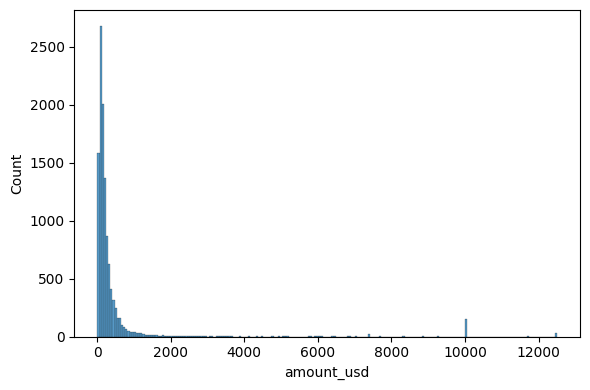

In [153]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.histplot(df.amount_usd, ax = ax)

plt.tight_layout()
plt.show()

In [154]:
df.loc[(df.fee.notnull()) & (df.fee > 500), "fee"].value_counts()

fee
9999.99    103
Name: count, dtype: int64

In [155]:
df.amount_usd.max(), df.fee.quantile(0.99)

(np.float64(12498.58), np.float64(152.03879999999995))

In [156]:
fee_df = df.loc[(df.fee.notnull()) & (df.fee < df.fee.max()) & (df.fee > 0), ["fee", "amount_usd", "source_currency"]]
fee_df.reset_index(drop = True, inplace = True)
fee_df.head()

,fee,amount_usd,source_currency
0,4.25,278.19,USD
1,4.24,154.29,CAD
2,2.70,160.33,USD
3,2.22,59.41,USD
4,3.61,200.96,USD


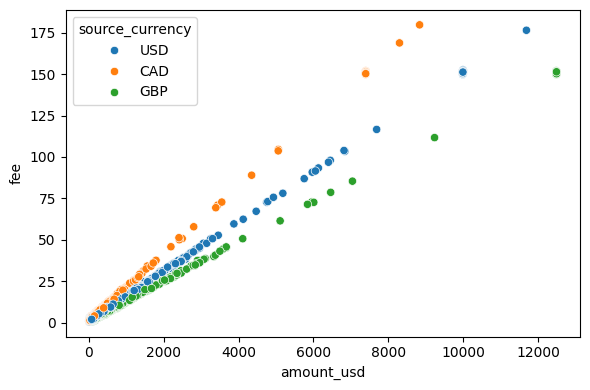

In [157]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.scatterplot(data = fee_df, x = "amount_usd", y = "fee", hue = "source_currency", ax = ax)

plt.tight_layout()
plt.show()

In [158]:
currency_fee_norm = {}
for curr in ["USD", "CAD", "GBP"]:
    t = fee_df.loc[fee_df.source_currency == curr].reset_index(drop = True)
    fee_mean, fee_std = t.fee.mean(), t.fee.std()
    amount_mean, amount_std = t.amount_usd.mean(), t.amount_usd.std()
    currency_fee_norm[curr] = [(fee_mean, fee_std), (amount_mean, amount_std)]

In [159]:
currency_fee_norm.get("GBP")[0][0]

np.float64(7.395856790123457)

In [160]:
models = {}
for curr in ["USD", "CAD", "GBP"]:
    t = fee_df.loc[fee_df.source_currency == curr].reset_index(drop = True)
    y = (t.fee - currency_fee_norm[curr][0][0]) / currency_fee_norm[curr][0][1]
    X = (t.amount_usd - currency_fee_norm[curr][1][0]) / currency_fee_norm[curr][1][1]

    lr = linregress(X.values, y.values)
    models[curr] = (lr.intercept, lr.slope)

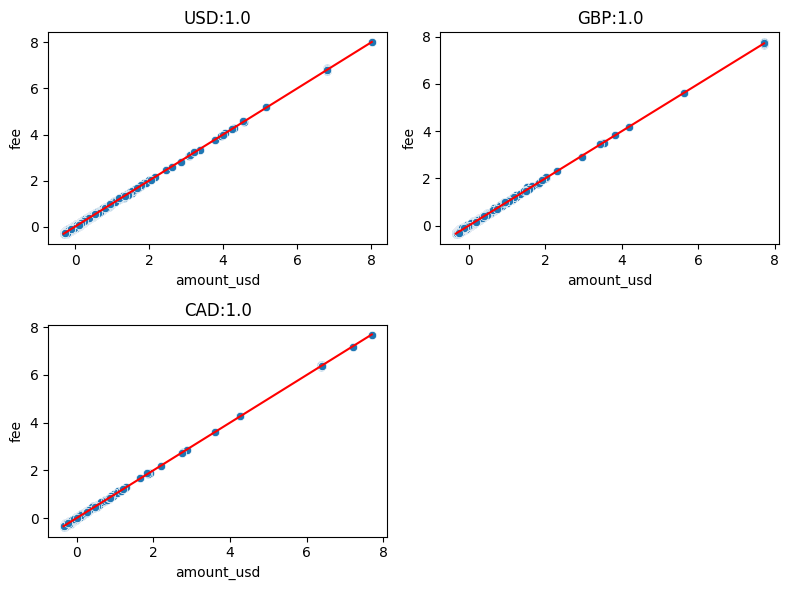

In [161]:
fig, ax = plt.subplots(2, 2, figsize = (8, 6))

for i, curr in enumerate(["USD", "GBP", "CAD"]):
    row, col =  i // 2, i % 2
    t = fee_df.loc[fee_df.source_currency == curr].reset_index(drop = True)
    X = (t.amount_usd - currency_fee_norm[curr][1][0]) / currency_fee_norm[curr][1][1]
    y = (t.fee - currency_fee_norm[curr][0][0]) / currency_fee_norm[curr][0][1]
    y_hat = models[curr][0] + (X * models[curr][1]) 
    
    sns.scatterplot(x = X, y = y, ax = ax[row, col])
    sns.lineplot(x = X, y = y_hat, color = "r", ax = ax[row, col])

    ax[row, col].set_title(f"{curr}:{round(models[curr][1], 3)}")


ax[1, 1].remove()

plt.tight_layout()
plt.show()

In [162]:
currency_fee_norm["USD"][1]

(np.float64(441.7637529258778), np.float64(1402.334194148055))

In [163]:
fee_df.head()

,fee,amount_usd,source_currency
0,4.25,278.19,USD
1,4.24,154.29,CAD
2,2.70,160.33,USD
3,2.22,59.41,USD
4,3.61,200.96,USD


In [164]:
def predict(currency: str, amount_usd: float) -> float:
    fee_mean, fee_std = currency_fee_norm[currency][0][0], currency_fee_norm[currency][0][1]
    amount_mean, amount_std = currency_fee_norm[currency][1][0], currency_fee_norm[currency][1][1]
    slope, intercept = models[currency][1], models[currency][0]
    x = (amount_usd - amount_mean) / amount_std
    y = intercept + (x * slope)

    return round((y * fee_std) + fee_mean, 2)

In [165]:
df.loc[df.fee.isnull(), "fee"] = df.loc[df.fee.isnull(), ["source_currency", "amount_usd"]].apply(lambda x: predict(x.source_currency, x.amount_usd), axis = 1)

In [166]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                      61
dtype: int64

In [167]:
dts = df.loc[
    (df.device_trust_score.notnull()),
    ["customer_id", "device_id", "device_trust_score"]
].groupby(by = ["customer_id", "device_id"]).aggregate({"device_trust_score": pd.Series.nunique})

dts.head()

,,device_trust_score
customer_id,device_id,
0006f893-10a8-4235-831b-fcae1e3f0140,609547e5-d0f9-4a82-bbda-29a503788d0b,1
00147b79-11ed-4f8f-a3af-651778b78dd3,1fe01c85-189b-4c49-a0c9-0e8f98fe1d80,1
00668d83-6f9f-4401-9a0f-04f94140abb6,113f3ae6-3670-4594-a672-0eec0a44c357,1
00957a15-945f-4bfb-b5fc-d867cbaee95d,59639db6-5600-4607-8f55-9b09db5b7f8f,1
00ab675d-a6ea-4d6e-bcdf-79027ce4f944,76cd2a3b-3659-4f2c-b1c9-22717bebec13,1


In [168]:
dts_ = df.loc[
    (df.device_trust_score.notnull()),
    ["customer_id", "device_id", "device_trust_score"]
].groupby(by = ["customer_id", "device_id"]).aggregate({"device_trust_score": "unique"})

dts_.head()

,,device_trust_score
customer_id,device_id,
0006f893-10a8-4235-831b-fcae1e3f0140,609547e5-d0f9-4a82-bbda-29a503788d0b,[0.182]
00147b79-11ed-4f8f-a3af-651778b78dd3,1fe01c85-189b-4c49-a0c9-0e8f98fe1d80,[0.169]
00668d83-6f9f-4401-9a0f-04f94140abb6,113f3ae6-3670-4594-a672-0eec0a44c357,[0.947]
00957a15-945f-4bfb-b5fc-d867cbaee95d,59639db6-5600-4607-8f55-9b09db5b7f8f,[0.369]
00ab675d-a6ea-4d6e-bcdf-79027ce4f944,76cd2a3b-3659-4f2c-b1c9-22717bebec13,[0.761]


In [169]:
dts.rename(columns = {"device_trust_score": "score_count"}, inplace = True)
dts_.rename(columns = {"device_trust_score": "score"}, inplace = True)

In [172]:
trust_score = pd.merge(
    dts,
    dts_,
    how = "inner",
    left_index = True,
    right_index = True
)

In [214]:
trust_score.score_count.unique()

array([1, 2, 3])

In [175]:
trust_score.loc[trust_score.score_count > 2].head(10)

score_count  \
customer_id                          device_id                                           
140d2232-ee97-4934-81aa-9e5c323d7c6f 49fd6714-a356-498c-bfed-f9b90c616d9e            3   
                                     bee245a7-0c95-4ceb-bec2-fcd258bf5366            3   
                                     f88d5270-4bb5-4a23-b30a-1067eb941a69            3   
23d9943d-57b1-42eb-9ef2-05eed7fd1957 1f81d60c-25b5-495c-a49c-b59a3aa4fb3a            3   
                                     8ecdcffb-4c5e-4ff3-b499-abc221b139dc            3   
                                     cc804c5d-939e-4ab0-bc97-5e01b9ab5791            3   
402cccc9-28de-45b3-9af7-cc5302aa1f93 00cfd083-289d-4583-9d1b-704417a347c2            3   
                                     01fb2040-f72b-4617-8222-81ced7985684            3   
                                     048d15d2-34e5-4b99-ac31-76634abcd265            3   
                                     07c00c92-4a83-4cfe-a2f0-533933a4da3a            3   

                                                                                          score  
customer_id                          device_id                                                   
140d2232-ee97-4934-81aa-9e5c323d7c6f 49fd6714-a356-498c-bfed-f9b90c616d9e  [0.607, 0.457, -0.1]  
                                     bee245a7-0c95-4ceb-bec2-fcd258bf5366  [0.607, -0.1, 0.457]  
                                     f88d5270-4bb5-4a23-b30a-1067eb941a69  [0.607, -0.1, 0.457]  
23d9943d-57b1-42eb-9ef2-05eed7fd1957 1f81d60c-25b5-495c-a49c-b59a3aa4fb3a  [0.953, 0.803, -0.1]  
                                     8ecdcffb-4c5e-4ff3-b499-abc221b139dc  [0.953, -0.1, 0.803]  
                                     cc804c5d-939e-4ab0-bc97-5e01b9ab5791  [0.953, -0.1, 0.803]  
402cccc9-28de-45b3-9af7-cc5302aa1f93 00cfd083-289d-4583-9d1b-704417a347c2  [0.522, -0.1, 0.372]  
                                     01fb2040-f72b-4617-8222-81ced7985684  [0.522, -0.1, 0.372]  
                                     048d15d2-34e5-4b99-ac31-76634abcd265  [0.522, -0.1, 0.372]  
                                     07c00c92-4a83-4cfe-a2f0-533933a4da3a  [0.522, -0.1, 0.372]

In [177]:
trust_score.loc[trust_score.score_count == 1, "score"].shape

(1398,)

In [176]:
trust_score.loc[trust_score.score_count == 1, "score"].apply(lambda x: -0.1 in x).sum()

np.int64(2)

In [178]:
trust_score.loc[trust_score.score_count == 2, "score"].shape

(586,)

In [180]:
trust_score.loc[trust_score.score_count == 2, "score"].apply(lambda x: -0.1 in x).sum()

np.int64(38)

In [183]:
trust_score.loc[trust_score.score_count > 2, "score"].shape

(128,)

In [185]:
trust_score.loc[trust_score.score_count > 2, "score"].apply(lambda x: -0.1 in x).sum()

np.int64(128)

In [187]:
df.loc[(df.ip_address.notnull()) & (df.device_trust_score < 0), ["customer_id", "ip_address", "device_trust_score"]]

,customer_id,ip_address,device_trust_score
51,402cccc9-28de-45b3-9af7-cc5302aa1f93,71.133.231.78,-0.1
60,d71c91b4-fee8-4104-9856-a5c6109a62e3,102.188.190.205,-0.1
78,70a93d26-8e3a-4179-900c-a4a7a74d08e5,154.171.88.114,-0.1
225,7bd5200c-5d19-44f0-9afe-8b339a05366b,51.190.9.19,-0.1
328,d71c91b4-fee8-4104-9856-a5c6109a62e3,223.51.189.238,-0.1
...,...,...,...
9982,d71c91b4-fee8-4104-9856-a5c6109a62e3,195.144.215.27,-0.1
10001,af8ca4c4-8703-4c55-b66c-2b76cd70040d,214.69.54.29,-0.1
10006,140d2232-ee97-4934-81aa-9e5c323d7c6f,86.94.79.160,-0.1
10131,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,74.138.217.202,-0.1


In [ ]:
df.loc[df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93", "device_trust_score"].value_counts()

device_trust_score
 0.522    1308
 0.372     139
-0.100      23
Name: count, dtype: int64

In [193]:
df.loc[(df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93") & (df.device_trust_score == 0.522), "new_device"].value_counts()

new_device
False    1308
Name: count, dtype: int64

In [192]:
df.loc[(df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93") & (df.device_trust_score == 0.372), "new_device"].value_counts()

new_device
True    139
Name: count, dtype: int64

In [194]:
df.loc[(df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93") & (df.device_trust_score < 0), "new_device"].value_counts()

new_device
False    21
True      2
Name: count, dtype: int64

In [199]:
df.loc[(df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93") & (df.datetime > "2023-03-28") & (df.datetime < "2023-04-28"), ["datetime", "new_device", "device_trust_score"]]

,datetime,new_device,device_trust_score
427,2023-04-13 05:27:05.468549+00:00,False,0.522
691,2023-04-16 10:56:06.468549+00:00,False,0.522
1579,2023-03-28 05:21:55.468549+00:00,False,0.522
1590,2023-03-29 06:22:42.468549+00:00,False,0.522
1591,2023-03-29 07:21:43.468549+00:00,False,0.522
1593,2023-03-29 11:59:27.468549+00:00,False,0.522
1603,2023-03-30 13:13:50.468549+00:00,True,0.372
1617,2023-03-31 16:54:19.468549+00:00,True,0.372
1622,2023-04-01 10:49:50.468549+00:00,False,0.522
1623,2023-04-01 12:50:20.468549+00:00,False,0.522


In [195]:
df.loc[(df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93") & (df.device_trust_score < 0), ["datetime", "new_device"]]

,datetime,new_device
51,2022-10-09 08:57:10.468549+00:00,False
596,2023-04-28 13:36:41.468549+00:00,True
655,2022-12-17 10:21:00.468549+00:00,False
1246,2023-02-16 08:19:20.468549+00:00,False
1418,2023-03-11 14:21:45.468549+00:00,False
1429,2023-03-12 19:53:56.468549+00:00,False
2105,2023-05-25 11:22:17.468549+00:00,False
2770,2023-08-08 11:47:55.468549+00:00,False
3744,2023-11-20 16:03:08.468549+00:00,False
4095,2023-12-28 17:24:26.468549+00:00,False


In [398]:
df.loc[
    df.customer_id == "23d9943d-57b1-42eb-9ef2-05eed7fd1957",
    "device_id"
].value_counts()

device_id
155f2330-d8da-4ca2-80c7-746334918b3f    70
793ba2dc-4410-46c8-81d7-78a44b268612    58
8ecdcffb-4c5e-4ff3-b499-abc221b139dc    48
1f81d60c-25b5-495c-a49c-b59a3aa4fb3a    26
1bbcba69-0f10-499b-9d26-3d9b59cc3dfc    24
80a924c6-69f0-4c32-8aab-b4146c327643    24
a4dd426f-a9c1-4f1e-942a-521614130a1d    23
cc804c5d-939e-4ab0-bc97-5e01b9ab5791    22
51e83f09-594a-4ab9-beba-135d88795a48    15
87733586-2660-4a56-8e87-651bc6cdca8f    13
69e8f2d8-1ff0-45e0-92c0-34bfcb54c80f    11
6eeb6f4d-82b6-481e-a0c6-2c1083e9b147     4
a952ef17-8827-4a63-9fcc-7611601e68a3     3
c5bca830-2611-4eb4-8ca1-c91e75c2702c     3
3926e5eb-8ff6-424d-b550-d895de32cf85     1
8512bb28-d86a-4275-8b6b-f61cee917d32     1
cd0421a3-3db7-4564-915c-44891437b089     1
Name: count, dtype: int64

In [399]:
df.loc[
    df.customer_id == "23d9943d-57b1-42eb-9ef2-05eed7fd1957",
    "device_trust_score"
].value_counts()

device_trust_score
 0.953    314
 0.803     15
-0.100      7
Name: count, dtype: int64

In [400]:
df.loc[
    (df.customer_id == "23d9943d-57b1-42eb-9ef2-05eed7fd1957"),
    ["customer_id", "device_id", "datetime", "device_trust_score", "new_device"]
].sort_values(by = ["datetime"], ascending = [True]).head(50)

,customer_id,device_id,datetime,device_trust_score,new_device
128,23d9943d-57b1-42eb-9ef2-05eed7fd1957,1f81d60c-25b5-495c-a49c-b59a3aa4fb3a,2022-10-18 13:15:13.468549+00:00,0.953,False
164,23d9943d-57b1-42eb-9ef2-05eed7fd1957,8ecdcffb-4c5e-4ff3-b499-abc221b139dc,2022-10-22 02:56:16.468549+00:00,0.953,False
243,23d9943d-57b1-42eb-9ef2-05eed7fd1957,793ba2dc-4410-46c8-81d7-78a44b268612,2022-10-30 15:36:39.468549+00:00,0.953,False
246,23d9943d-57b1-42eb-9ef2-05eed7fd1957,793ba2dc-4410-46c8-81d7-78a44b268612,2022-10-30 19:56:41.468549+00:00,0.953,False
265,23d9943d-57b1-42eb-9ef2-05eed7fd1957,155f2330-d8da-4ca2-80c7-746334918b3f,2022-11-02 06:49:40.468549+00:00,0.953,False
286,23d9943d-57b1-42eb-9ef2-05eed7fd1957,155f2330-d8da-4ca2-80c7-746334918b3f,2022-11-04 18:46:29.468549+00:00,0.953,False
310,23d9943d-57b1-42eb-9ef2-05eed7fd1957,155f2330-d8da-4ca2-80c7-746334918b3f,2022-11-07 21:13:38.468549+00:00,0.953,False
314,23d9943d-57b1-42eb-9ef2-05eed7fd1957,51e83f09-594a-4ab9-beba-135d88795a48,2022-11-08 09:32:58.468549+00:00,0.953,False
426,23d9943d-57b1-42eb-9ef2-05eed7fd1957,8ecdcffb-4c5e-4ff3-b499-abc221b139dc,2022-11-22 04:45:52.468549+00:00,0.953,False
448,23d9943d-57b1-42eb-9ef2-05eed7fd1957,793ba2dc-4410-46c8-81d7-78a44b268612,2022-11-23 18:39:56.468549+00:00,0.953,False


In [202]:
df.loc[(df.device_trust_score > 0) & (df.new_device)].groupby(by = ["customer_id"]).aggregate({"device_trust_score": "nunique"}).device_trust_score.unique()

array([1])

In [208]:
new_device = df.loc[(df.device_trust_score > 0) & (df.new_device), ["customer_id", "device_trust_score"]].drop_duplicates().set_index("customer_id").device_trust_score.to_dict()

In [209]:
old_device = df.loc[(df.device_trust_score > 0) & (~df.new_device), ["customer_id", "device_trust_score"]].drop_duplicates().set_index("customer_id").device_trust_score.to_dict()

In [211]:
new_device.get("23d9943d-57b1-42eb-9ef2-05eed7fd1957")

0.803

In [212]:
old_device.get("23d9943d-57b1-42eb-9ef2-05eed7fd1957")

0.953

In [225]:
df.loc[df.device_trust_score.isnull(), "device_trust_score"] = df.loc[df.device_trust_score.isnull(), ["customer_id", "new_device"]].apply(lambda x: new_device.get(x.customer_id) if x.new_device else old_device.get(x.customer_id), axis = 1)

In [226]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             2
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                      61
dtype: int64

In [234]:
df.loc[df.fee == 9999.99, "fee"] = df.loc[df.fee == 9999.99, ["source_currency", "amount_usd"]].apply(lambda x: predict(x.source_currency, x.amount_usd), axis = 1)

In [236]:
df.ip_country.value_counts(normalize = True).round(4) * 100

ip_country
US         62.37
UK         21.86
CA         15.47
unknown     0.30
Name: proportion, dtype: float64

In [237]:
df.loc[df.ip_address.isnull(), "ip_risk_score"]

13       0.245
49       0.530
151      0.310
163      0.519
168      0.655
         ...  
10054    0.434
10082    0.446
10093    0.451
10142    0.474
10162    0.332
Name: ip_risk_score, Length: 305, dtype: float64

In [255]:
df.loc[df.device_trust_score.isnull(), ["datetime", "customer_id", "device_id", "ip_address", "ip_risk_score", "home_country", "ip_country", "location_mismatch"]]

,datetime,customer_id,device_id,ip_address,ip_risk_score,home_country,ip_country,location_mismatch
536,2022-12-05 00:45:02.468549+00:00,691bb730-3142-40b3-a64f-0e54dc199252,9593519b-5581-40a2-a502-f17e3d790671,NaN,0.342,UK,UK,False
4200,2024-01-09 03:16:26.468549+00:00,691bb730-3142-40b3-a64f-0e54dc199252,9593519b-5581-40a2-a502-f17e3d790671,NaN,0.206,UK,UK,False


In [262]:
first_dts = df.loc[(df.datetime.notnull()) & (df.device_trust_score.notnull()), ["datetime", "customer_id", "device_trust_score", "ip_risk_score"]].sort_values(by = ["datetime"], ascending = [True]).reset_index(drop = True)
first_dts.head()

,datetime,customer_id,device_trust_score,ip_risk_score
0,2022-10-03 18:40:59.468549+00:00,402cccc9-28de-45b3-9af7-cc5302aa1f93,0.522,0.123
1,2022-10-03 20:39:38.468549+00:00,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,0.475,0.569
2,2022-10-03 23:02:43.468549+00:00,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,0.939,0.437
3,2022-10-04 01:08:53.468549+00:00,7bd5200c-5d19-44f0-9afe-8b339a05366b,0.551,0.594
4,2022-10-04 09:35:03.468549+00:00,70a93d26-8e3a-4179-900c-a4a7a74d08e5,0.894,0.121


In [263]:
first_dts = first_dts.drop_duplicates(subset= ["customer_id"], keep = "first")

In [264]:
first_dts.head()

,datetime,customer_id,device_trust_score,ip_risk_score
0,2022-10-03 18:40:59.468549+00:00,402cccc9-28de-45b3-9af7-cc5302aa1f93,0.522,0.123
1,2022-10-03 20:39:38.468549+00:00,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,0.475,0.569
2,2022-10-03 23:02:43.468549+00:00,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,0.939,0.437
3,2022-10-04 01:08:53.468549+00:00,7bd5200c-5d19-44f0-9afe-8b339a05366b,0.551,0.594
4,2022-10-04 09:35:03.468549+00:00,70a93d26-8e3a-4179-900c-a4a7a74d08e5,0.894,0.121


In [267]:
first_dts.loc[:, ["device_trust_score", "ip_risk_score"]].corr()

,device_trust_score,ip_risk_score
device_trust_score,1.000000,-0.824044
ip_risk_score,-0.824044,1.000000


In [268]:
reg = linregress(first_dts.ip_risk_score.values, first_dts.device_trust_score)

In [278]:
dts_hat = list(map(lambda x: round(x * reg.slope + reg.intercept, 3), first_dts.ip_risk_score.tolist()))

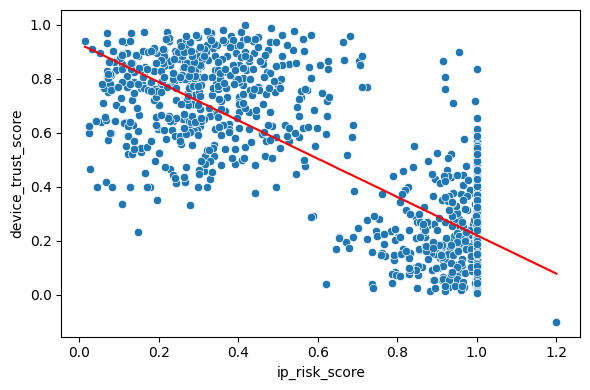

In [280]:
fig, ax = plt.subplots(figsize = (6, 4))


sns.scatterplot(x = first_dts.ip_risk_score, y = first_dts.device_trust_score, ax = ax)
sns.lineplot(x = first_dts.ip_risk_score, y = dts_hat, color = 'red', ax = ax)

plt.tight_layout()
plt.show()

In [284]:
df.loc[df.device_trust_score.isnull(), "device_trust_score"] = df.loc[df.device_trust_score.isnull(), "ip_risk_score"].apply(lambda x: x * reg.slope + reg.intercept).round(3)

In [289]:
customers = df.loc[df.datetime.isnull(), "customer_id"].unique().tolist()

In [290]:
df.loc[df.customer_id.isin(customers), "customer_id"].value_counts()

customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
7bd5200c-5d19-44f0-9afe-8b339a05366b     811
70a93d26-8e3a-4179-900c-a4a7a74d08e5     677
f7531a78-8bbe-4a85-b1e8-a0650edddc72     394
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad     360
140d2232-ee97-4934-81aa-9e5c323d7c6f     163
66c71a44-d07c-4a20-a576-0a377193bf6b     151
f0f8ede3-6dfe-42d9-bcee-9eec672c0f7d      33
07869ce6-0e8d-4f0a-b1ee-2e1dcad78f95      22
6310c205-42bb-4295-b4dc-2a6128a1c1f0      12
4fa7972c-e13c-4c84-a509-332fc7da9575      11
Name: count, dtype: int64

In [320]:
customer_df = df.loc[(df.customer_id.isin(customers)) & (df.datetime.notnull()), ["datetime", "customer_id"]]

In [321]:
customer_df.reset_index(drop = True, inplace = True)

In [322]:
customer_df.head()

,datetime,customer_id
0,2022-10-03 18:40:59.468549+00:00,402cccc9-28de-45b3-9af7-cc5302aa1f93
1,2022-10-03 20:39:38.468549+00:00,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad
2,2022-10-03 23:02:43.468549+00:00,6d0d9b27-fa26-45f8-93b1-2df29d182d9c
3,2022-10-04 01:08:53.468549+00:00,7bd5200c-5d19-44f0-9afe-8b339a05366b
4,2022-10-04 09:35:03.468549+00:00,70a93d26-8e3a-4179-900c-a4a7a74d08e5


In [323]:
customer_df["interval"] = customer_df.loc[customer_df.customer_id.isin(customers)].groupby(by = ["customer_id"])["datetime"].transform(lambda x: x.sort_values().diff().dt.total_seconds())

In [339]:
customer_hours = (customer_df.dropna(subset = ["interval"]).groupby(by = ["customer_id"])["interval"].mean() / 3_600).round().to_dict()

In [346]:
customer_df.interval = customer_df.interval.apply(lambda x: round(x / 3_600) if np.nan_to_num(x) else np.nan)

In [351]:
def check_space(customer_id: str, interval: float) -> bool:
    if not np.nan_to_num(interval):
        return False
    
    customer_interval = customer_hours.get(customer_id)
    if interval > customer_interval:
        return True
    return False

In [353]:
customer_df["position"] = customer_df.apply(lambda x: check_space(x.customer_id, x.interval), axis = 1)

In [355]:
customer_df.groupby(by = ["customer_id"])["position"].any()

customer_id
07869ce6-0e8d-4f0a-b1ee-2e1dcad78f95    True
140d2232-ee97-4934-81aa-9e5c323d7c6f    True
402cccc9-28de-45b3-9af7-cc5302aa1f93    True
4fa7972c-e13c-4c84-a509-332fc7da9575    True
6310c205-42bb-4295-b4dc-2a6128a1c1f0    True
66c71a44-d07c-4a20-a576-0a377193bf6b    True
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad    True
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    True
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    True
70a93d26-8e3a-4179-900c-a4a7a74d08e5    True
7bd5200c-5d19-44f0-9afe-8b339a05366b    True
af8ca4c4-8703-4c55-b66c-2b76cd70040d    True
d71c91b4-fee8-4104-9856-a5c6109a62e3    True
f0f8ede3-6dfe-42d9-bcee-9eec672c0f7d    True
f7531a78-8bbe-4a85-b1e8-a0650edddc72    True
Name: position, dtype: bool

In [358]:
customer_df.loc[customer_df.position].sort_values(by = ["datetime"], ascending = [True]).drop_duplicates(subset = ["customer_id"], keep = "first")

,datetime,customer_id,interval,position
12,2022-10-05 13:34:02.468549+00:00,7bd5200c-5d19-44f0-9afe-8b339a05366b,36.0,True
17,2022-10-06 01:21:47.468549+00:00,d71c91b4-fee8-4104-9856-a5c6109a62e3,24.0,True
18,2022-10-06 04:25:15.468549+00:00,402cccc9-28de-45b3-9af7-cc5302aa1f93,58.0,True
30,2022-10-07 11:46:35.468549+00:00,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,53.0,True
36,2022-10-08 08:19:24.468549+00:00,af8ca4c4-8703-4c55-b66c-2b76cd70040d,37.0,True
37,2022-10-08 13:33:03.468549+00:00,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,28.0,True
45,2022-10-09 13:43:14.468549+00:00,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,121.0,True
61,2022-10-11 22:21:22.468549+00:00,70a93d26-8e3a-4179-900c-a4a7a74d08e5,151.0,True
75,2022-10-15 08:10:39.468549+00:00,f7531a78-8bbe-4a85-b1e8-a0650edddc72,95.0,True
219,2022-11-02 00:38:48.468549+00:00,140d2232-ee97-4934-81aa-9e5c323d7c6f,451.0,True


In [379]:
customer_size = df.loc[(df.customer_id.isin(customers)) & (df.datetime.isnull()), "customer_id"].value_counts().to_dict()
customer_size

{'7041b9c1-3719-4ca8-9a6b-811b47cea6c0': 12,
 '402cccc9-28de-45b3-9af7-cc5302aa1f93': 10,
 'd71c91b4-fee8-4104-9856-a5c6109a62e3': 9,
 '6d0d9b27-fa26-45f8-93b1-2df29d182d9c': 7,
 '7bd5200c-5d19-44f0-9afe-8b339a05366b': 4,
 'af8ca4c4-8703-4c55-b66c-2b76cd70040d': 4,
 '140d2232-ee97-4934-81aa-9e5c323d7c6f': 3,
 '70a93d26-8e3a-4179-900c-a4a7a74d08e5': 2,
 '66c71a44-d07c-4a20-a576-0a377193bf6b': 2,
 'f7531a78-8bbe-4a85-b1e8-a0650edddc72': 2,
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad': 2,
 '4fa7972c-e13c-4c84-a509-332fc7da9575': 1,
 '07869ce6-0e8d-4f0a-b1ee-2e1dcad78f95': 1,
 '6310c205-42bb-4295-b4dc-2a6128a1c1f0': 1,
 'f0f8ede3-6dfe-42d9-bcee-9eec672c0f7d': 1}

In [380]:
customer_hours

{'07869ce6-0e8d-4f0a-b1ee-2e1dcad78f95': 1267.0,
 '140d2232-ee97-4934-81aa-9e5c323d7c6f': 163.0,
 '402cccc9-28de-45b3-9af7-cc5302aa1f93': 18.0,
 '4fa7972c-e13c-4c84-a509-332fc7da9575': 2114.0,
 '6310c205-42bb-4295-b4dc-2a6128a1c1f0': 1993.0,
 '66c71a44-d07c-4a20-a576-0a377193bf6b': 175.0,
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad': 75.0,
 '6d0d9b27-fa26-45f8-93b1-2df29d182d9c': 27.0,
 '7041b9c1-3719-4ca8-9a6b-811b47cea6c0': 21.0,
 '70a93d26-8e3a-4179-900c-a4a7a74d08e5': 40.0,
 '7bd5200c-5d19-44f0-9afe-8b339a05366b': 33.0,
 'af8ca4c4-8703-4c55-b66c-2b76cd70040d': 29.0,
 'd71c91b4-fee8-4104-9856-a5c6109a62e3': 20.0,
 'f0f8ede3-6dfe-42d9-bcee-9eec672c0f7d': 734.0,
 'f7531a78-8bbe-4a85-b1e8-a0650edddc72': 71.0}

In [400]:
customer_hours.get("f0f8ede3-6dfe-42d9-bcee-9eec672c0f7d")

734.0

In [398]:
def place_date(customer_id: str):
    transaction_date = df.loc[df.customer_id == customer_id, "datetime"].dropna().sort_values(ascending = [True]).tolist()
    size = customer_size.get(customer_id)
    average_interval = customer_hours.get(customer_id)

    missing_date = []
    previous_date = transaction_date[0]
    
    for date in transaction_date[1:]:
        interval = (date - previous_date).total_seconds() / 3_600
        while interval > average_interval:
            missing_date.append(previous_date:=previous_date + pd.Timedelta(hours = average_interval))
            if len(missing_date) == size:
                return missing_date
        previous_date = date
    
    while len(missing_date) < size:
        missing_date.append(previous_date:=previous_date + pd.Timedelta(hours = average_interval))
    
    return missing_date

In [403]:
for customer in customers:
    df.loc[(df.customer_id == customer) & (df.datetime.isnull()), "datetime"] = place_date(customer)

In [404]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                       0
dtype: int64

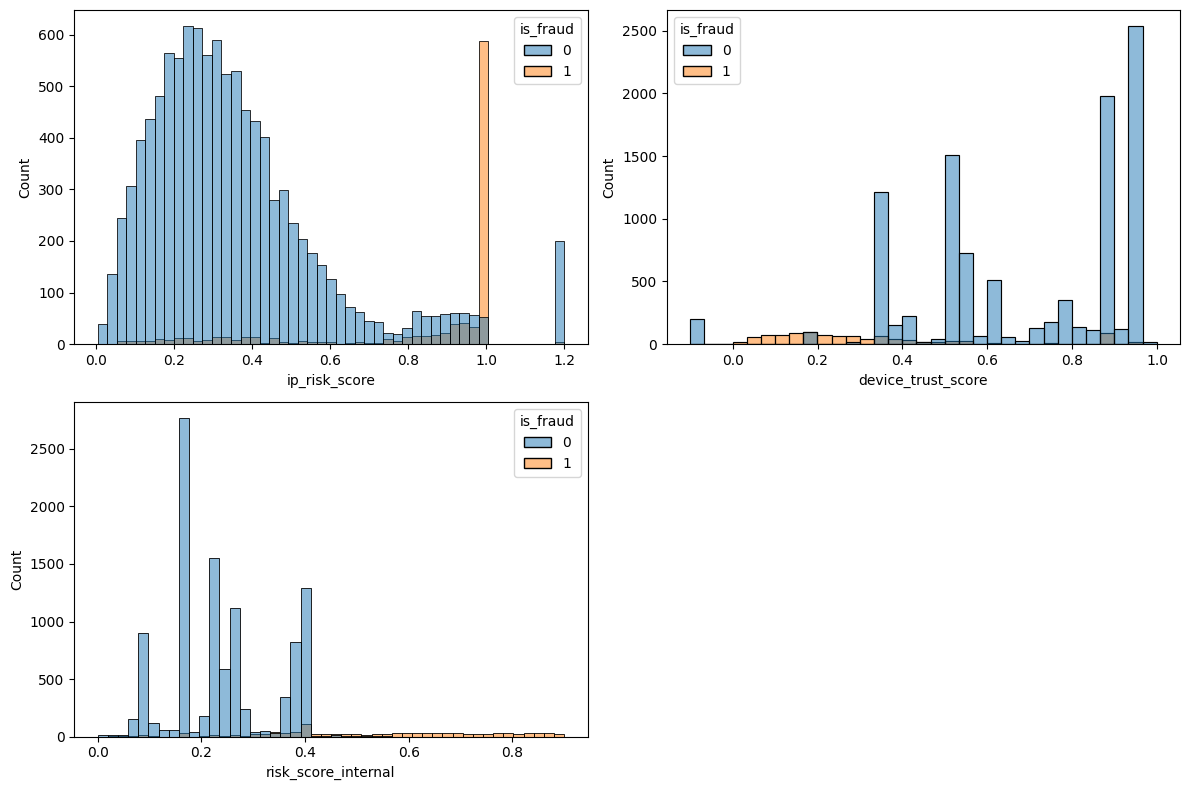

In [412]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))

sns.histplot(df.loc[:, ["ip_risk_score", "is_fraud"]], x = "ip_risk_score",  hue = "is_fraud", ax = ax[0, 0])
sns.histplot(df.loc[:, ["device_trust_score", "is_fraud"]], x = "device_trust_score",  hue = "is_fraud", ax = ax[0, 1])

sns.histplot(df.loc[:, ["risk_score_internal", "is_fraud"]], x = "risk_score_internal",  hue = "is_fraud", ax = ax[1, 0])

ax[1, 1].remove()

plt.tight_layout()
plt.show()

In [414]:
df.to_csv("../data/cleaned_data.csv", index = False)

In [396]:
df.loc[
    df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93",
    "device_trust_score"
].value_counts()

device_trust_score
 0.522    1308
 0.372     139
-0.100      23
Name: count, dtype: int64

In [397]:
df.loc[
    (df.customer_id == "402cccc9-28de-45b3-9af7-cc5302aa1f93"),
    ["customer_id", "device_id", "datetime", "device_trust_score", "new_device"]
].sort_values(by = ["datetime"], ascending = [True]).head(50)

,customer_id,device_id,datetime,device_trust_score,new_device
0,402cccc9-28de-45b3-9af7-cc5302aa1f93,9f292dcc-3297-4947-a260-6a1ef69041ff,2022-10-03 18:40:59.468549+00:00,0.522,False
20,402cccc9-28de-45b3-9af7-cc5302aa1f93,5f187e9b-8172-42dc-83ec-95fb3182346b,2022-10-06 04:25:15.468549+00:00,0.522,False
26,402cccc9-28de-45b3-9af7-cc5302aa1f93,d132ac87-0ed0-4d66-a467-4d16430bdc1d,2022-10-06 10:06:36.468549+00:00,0.522,False
32,402cccc9-28de-45b3-9af7-cc5302aa1f93,33919fa4-5dbb-41b0-a895-ec15ab2c10f1,2022-10-07 08:31:21.468549+00:00,0.522,False
33,402cccc9-28de-45b3-9af7-cc5302aa1f93,0e07b0ec-41c2-404d-9214-cc165fb9ea1d,2022-10-07 08:48:11.468549+00:00,0.522,False
37,402cccc9-28de-45b3-9af7-cc5302aa1f93,32a0bc21-a7f6-42ae-b05c-b5a3d1064a01,2022-10-07 15:52:25.468549+00:00,0.522,False
49,402cccc9-28de-45b3-9af7-cc5302aa1f93,b823bda8-e2a3-4541-a8d3-ae59fc963dd7,2022-10-08 20:45:48.468549+00:00,NaN,False
51,402cccc9-28de-45b3-9af7-cc5302aa1f93,16e4b1b1-a590-45cf-b154-6b8edbcf0dbd,2022-10-09 08:57:10.468549+00:00,-0.100,False
10030,402cccc9-28de-45b3-9af7-cc5302aa1f93,9f5cc9be-f9f0-4911-bdc4-d9e4c8a871fa,2022-10-09 20:21:25.468549+00:00,0.522,False
57,402cccc9-28de-45b3-9af7-cc5302aa1f93,9f5cc9be-f9f0-4911-bdc4-d9e4c8a871fa,2022-10-09 20:21:25.468549+00:00,0.522,False


In [391]:
df.loc[
    df.customer_id == "140d2232-ee97-4934-81aa-9e5c323d7c6f",
    "device_id"
].value_counts()

device_id
9849347e-5774-4f24-ac70-de0c98536adf    73
85cd40a7-d1b8-49b4-9e11-55d18ba545ec    35
bee245a7-0c95-4ceb-bec2-fcd258bf5366    22
49fd6714-a356-498c-bfed-f9b90c616d9e    12
f88d5270-4bb5-4a23-b30a-1067eb941a69     9
08647428-403a-42d1-8139-72298ccb48d1     7
bc07f77f-b107-4b05-8e10-5d62f71ead8a     4
f75aa744-64ba-46b3-8e5f-7a8a7f79b3cd     1
Name: count, dtype: int64

In [392]:
df.loc[
    df.customer_id == "140d2232-ee97-4934-81aa-9e5c323d7c6f",
    "device_trust_score"
].value_counts()

device_trust_score
 0.607    147
-0.100      7
 0.457      7
Name: count, dtype: int64

In [393]:
df.loc[
    (df.customer_id == "140d2232-ee97-4934-81aa-9e5c323d7c6f") &
    (df.device_trust_score < 0),
    ["customer_id", "device_id", "datetime", "device_trust_score", "new_device"]
].sort_values(by = ["datetime"], ascending = [True]).head(30)

,customer_id,device_id,datetime,device_trust_score,new_device
758,140d2232-ee97-4934-81aa-9e5c323d7c6f,bee245a7-0c95-4ceb-bec2-fcd258bf5366,2022-12-28 03:49:03.468549+00:00,-0.1,False
3327,140d2232-ee97-4934-81aa-9e5c323d7c6f,9849347e-5774-4f24-ac70-de0c98536adf,2023-10-07 19:57:16.468549+00:00,-0.1,False
4648,140d2232-ee97-4934-81aa-9e5c323d7c6f,f88d5270-4bb5-4a23-b30a-1067eb941a69,2024-02-24 04:14:49.468549+00:00,-0.1,False
6508,140d2232-ee97-4934-81aa-9e5c323d7c6f,9849347e-5774-4f24-ac70-de0c98536adf,2024-09-14 09:31:14.468549+00:00,-0.1,False
10006,140d2232-ee97-4934-81aa-9e5c323d7c6f,9849347e-5774-4f24-ac70-de0c98536adf,2024-09-14 09:31:14.468549+00:00,-0.1,False
9113,140d2232-ee97-4934-81aa-9e5c323d7c6f,49fd6714-a356-498c-bfed-f9b90c616d9e,2025-06-29 13:52:29.468549+00:00,-0.1,False
9562,140d2232-ee97-4934-81aa-9e5c323d7c6f,f88d5270-4bb5-4a23-b30a-1067eb941a69,2025-08-18 17:07:07.468549+00:00,-0.1,False


In [394]:
df.loc[
    (df.customer_id == "140d2232-ee97-4934-81aa-9e5c323d7c6f"),
    ["customer_id", "device_id", "datetime", "device_trust_score", "new_device"]
].sort_values(by = ["datetime"], ascending = [True]).head(50)

,customer_id,device_id,datetime,device_trust_score,new_device
86,140d2232-ee97-4934-81aa-9e5c323d7c6f,f88d5270-4bb5-4a23-b30a-1067eb941a69,2022-10-14 05:25:12.468549+00:00,0.607,False
262,140d2232-ee97-4934-81aa-9e5c323d7c6f,9849347e-5774-4f24-ac70-de0c98536adf,2022-11-02 00:38:48.468549+00:00,0.607,False
330,140d2232-ee97-4934-81aa-9e5c323d7c6f,bee245a7-0c95-4ceb-bec2-fcd258bf5366,2022-11-10 04:17:52.468549+00:00,0.607,False
450,140d2232-ee97-4934-81aa-9e5c323d7c6f,85cd40a7-d1b8-49b4-9e11-55d18ba545ec,2022-11-24 03:57:36.468549+00:00,0.607,False
468,140d2232-ee97-4934-81aa-9e5c323d7c6f,85cd40a7-d1b8-49b4-9e11-55d18ba545ec,2022-11-26 09:54:35.468549+00:00,0.607,False
529,140d2232-ee97-4934-81aa-9e5c323d7c6f,f88d5270-4bb5-4a23-b30a-1067eb941a69,2022-12-03 14:59:23.468549+00:00,0.607,False
544,140d2232-ee97-4934-81aa-9e5c323d7c6f,85cd40a7-d1b8-49b4-9e11-55d18ba545ec,2022-12-06 05:35:08.468549+00:00,0.607,False
604,140d2232-ee97-4934-81aa-9e5c323d7c6f,9849347e-5774-4f24-ac70-de0c98536adf,2022-12-12 16:45:50.468549+00:00,0.607,False
730,140d2232-ee97-4934-81aa-9e5c323d7c6f,85cd40a7-d1b8-49b4-9e11-55d18ba545ec,2022-12-24 17:13:59.468549+00:00,0.607,False
758,140d2232-ee97-4934-81aa-9e5c323d7c6f,bee245a7-0c95-4ceb-bec2-fcd258bf5366,2022-12-28 03:49:03.468549+00:00,-0.100,False


In [384]:
df.channel = df.channel.str.strip().str.lower().replace({"mobille": "mobile", "weeb": "web"})

In [387]:
df.channel.value_counts()

channel
mobile     6521
web        3821
atm        1021
unknown      37
Name: count, dtype: int64

In [386]:
df.loc[
    df.device_trust_score < 0,
    "channel"
].value_counts()

channel
mobile    121
web        64
atm        19
Name: count, dtype: int64

In [390]:
df.loc[
    df.new_device,
    "device_trust_score"
]

1        0.475
14       0.401
18       0.784
21       0.680
23       0.186
         ...  
11385    0.324
11392    0.185
11393    0.238
11397    0.269
11399    0.187
Name: device_trust_score, Length: 1353, dtype: float64

In [458]:
df.loc[df.duplicated(subset = ["transaction_id"]), "txn_velocity_1h"].value_counts()

txn_velocity_1h
 0    187
-1      4
 5      3
 1      3
 6      2
 4      1
Name: count, dtype: int64

In [463]:
df.transaction_id.value_counts().head(20)

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
22566dff-8c67-4119-9d2d-fa23862199c8    2
a5c6391d-4763-4ed6-a5ef-80b744cf71b2    2
d111a38d-879a-4354-9666-82ce420b9f4a    2
4c80a822-dda8-46e0-a5f5-a621a24210b8    2
e952671a-33bc-4c98-9242-f47caad7741c    2
c0059f95-5daa-415b-b686-924d3ee4ca9b    2
88b5e91e-c9ba-4a58-b18f-a234a7a03cc8    2
883403f5-fd2f-4b39-824e-9710485a983e    2
a71aaac9-2819-4f46-9ec9-1f2699ecc2aa    2
35c133e7-7279-4d24-ac0e-967675f2c2a0    2
40049bb9-944d-4add-8f1f-06c2732e8a9d    2
f70c112d-9406-4ac9-b1fd-d31f4d972e0e    2
1174a4a4-d11e-423f-b212-c70a2986df4e    2
a96e7cc8-8d34-464d-8d93-b0dab38db30b    2
41ffc5f6-a17e-4a3e-97be-be4cf7f38860    2
Name: count, dtype: int64

In [464]:
df.loc[df.transaction_id == "4662cb2d-21b2-4390-ba38-5a1eddebdc7c"]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
57,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-09 20:21:25.468549+00:00,US,USD,GBP,mobile,152.75,152.75,3.35,0.8,9f5cc9be-f9f0-4911-bdc4-d9e4c8a871fa,False,194.179.17.152,US,False,0.328,standard,263,0.522,0,0.223,5,5,0.0,0,2022-10-09 20:21:25.468549+00:00
10030,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-09 20:21:25.468549+00:00,US,USD,GBP,mobile,152.75,152.75,3.35,0.8,9f5cc9be-f9f0-4911-bdc4-d9e4c8a871fa,False,194.179.17.152,US,False,0.328,standard,263,0.522,0,0.223,5,5,0.0,0,2022-10-09 20:21:25.468549+00:00


In [474]:
tid = df.loc[df.duplicated(subset = ["transaction_id"]), "transaction_id"].tolist()

In [466]:
df.loc[df.duplicated(subset = ["transaction_id"]), :].groupby(by = ["transaction_id"]).aggregate({"is_fraud": "nunique"}).is_fraud.unique()

array([1])

In [478]:
df.loc[df.transaction_id.isin(tid)].sort_values(by = ["datetime"], ascending = [True]).reset_index(drop = True).duplicated().sum()

np.int64(200)

In [479]:
df.loc[df.duplicated(subset = ["transaction_id"]), :].shape[0]

200

In [486]:
df.loc[df.txn_velocity_1h < 0, "is_fraud"].value_counts()

is_fraud
0    200
1      4
Name: count, dtype: int64

In [489]:
df.loc[(df.txn_velocity_1h < 0) & (df.is_fraud == 1), "risk_score_internal"]

4427    0.355
4562    0.407
5672    0.407
6454    0.407
Name: risk_score_internal, dtype: float64

In [491]:
df.loc[(df.txn_velocity_1h < 0) & (df.is_fraud == 0) & (df.risk_score_internal >= 0.35), "risk_score_internal"]

225      0.391
718      0.407
788      0.363
798      0.407
1093     0.407
1510     0.407
1638     0.407
1790     0.361
1926     0.391
2147     0.407
2167     0.391
2392     0.391
2563     0.391
2760     0.407
2792     0.407
2794     0.407
3313     0.407
3340     0.391
3873     0.407
3899     0.391
3903     0.391
4155     0.391
4216     0.407
4229     0.407
4261     0.407
4349     0.394
4378     0.391
4421     0.391
4499     0.407
4645     0.407
4669     0.407
4780     0.363
4812     0.407
4927     0.407
5623     0.366
5656     0.391
5770     0.407
6056     0.391
6369     0.407
6537     0.407
6802     0.407
7132     0.407
7150     0.391
7253     0.407
7425     0.391
7611     0.407
7916     0.355
8272     0.407
8442     0.407
8611     0.407
8680     0.407
9110     0.391
9174     0.407
9627     0.407
9796     0.407
9877     0.407
10131    0.407
10198    0.407
Name: risk_score_internal, dtype: float64

In [485]:
df.loc[df.txn_velocity_1h < 0, ["txn_velocity_1h", "device_trust_score", "ip_risk_score"]]

,txn_velocity_1h,device_trust_score,ip_risk_score
51,-1,-0.1,1.2
60,-1,-0.1,1.2
78,-1,-0.1,1.2
225,-1,-0.1,1.2
328,-1,-0.1,1.2
...,...,...,...
9982,-1,-0.1,1.2
10001,-1,-0.1,1.2
10006,-1,-0.1,1.2
10131,-1,-0.1,1.2


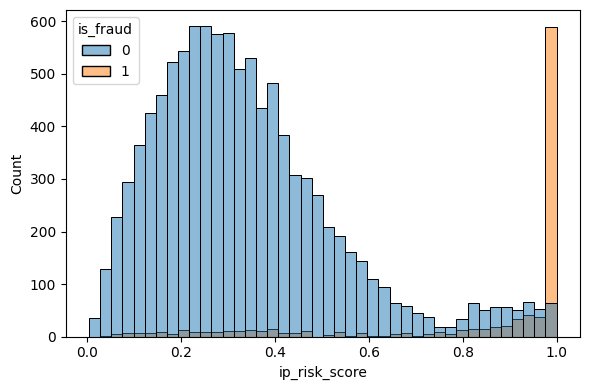

In [496]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.histplot(data = df.loc[df.ip_risk_score != 1.2, ["ip_risk_score", "is_fraud"]], x = "ip_risk_score", hue = "is_fraud", ax = ax)

plt.tight_layout()
plt.show()

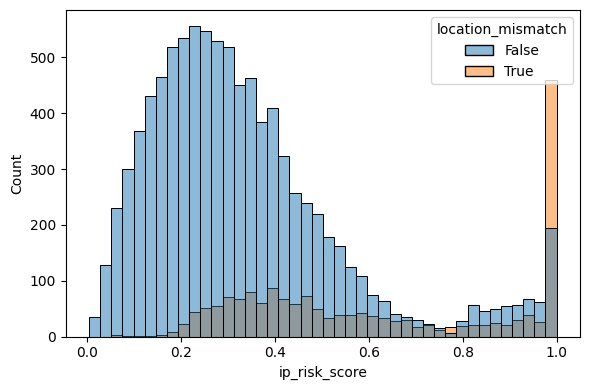

In [503]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.histplot(data = df.loc[df.ip_risk_score != 1.2, ["ip_risk_score", "location_mismatch"]], x = "ip_risk_score", hue = "location_mismatch", ax = ax)

plt.tight_layout()
plt.show()

In [498]:
df.loc[df.ip_risk_score > 1, "is_fraud"].mean()

np.float64(0.0196078431372549)

In [500]:
df.loc[(df.ip_risk_score >= 0.90) & (df.ip_risk_score < 1.2), "is_fraud"].mean()

np.float64(0.7392670157068063)

In [501]:
df.loc[df.ip_risk_score < 0.9, "is_fraud"].mean()

np.float64(0.028024606971975393)

In [502]:
df.loc[(df.ip_risk_score >= 0.90) & (df.ip_risk_score < 1.2), "location_mismatch"].mean()

np.float64(0.5842931937172775)

In [504]:
df.ip_country.value_counts()

ip_country
US         6921
UK         2431
CA         1742
unknown       2
Name: count, dtype: int64

In [506]:
df.loc[df.ip_country == "unknown"]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
8529,9b8f9e85-a616-44d1-afbd-b92a70ab90f3,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2025-04-28 14:44:40.468549+00:00,CA,CAD,EUR,mobile,120.43,89.12,2.38,0.685185,a2a10293-eaa6-4470-bb6d-8aa149d71e65,False,7.187.51.25,unknown,True,0.584,standard,947,0.625,0,0.268,8,9,0.0,0,2025-04-28 14:44:40.468549+00:00
9140,b9dfd0bd-378d-48d5-a3fb-3815751b37ca,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-07-02 21:57:48.468549+00:00,US,USD,EUR,mobile,47.55,47.55,1.33,0.925926,518f44cf-803d-4bc3-a4a9-2556340f5789,False,99.148.50.57,unknown,True,0.461,standard,298,0.336,0,0.166,0,0,0.0,0,2025-07-02 21:57:48.468549+00:00


In [510]:
df.ip_country.isnull().sum()

np.int64(304)

In [515]:
df.home_country.isnull().sum()

np.int64(0)

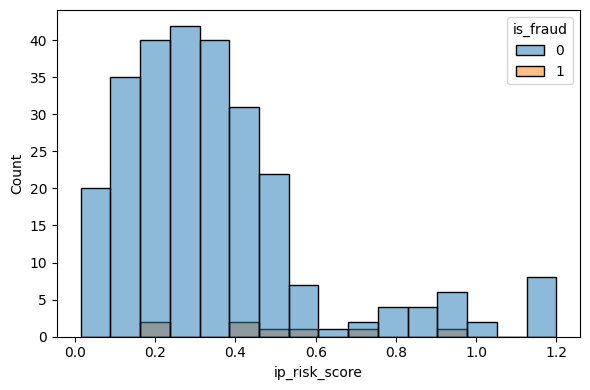

In [513]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.histplot(data = df.loc[(df.ip_country.isnull()) & (~df.location_mismatch), ["ip_risk_score", "is_fraud"]], x = "ip_risk_score", hue = "is_fraud", ax = ax)

plt.tight_layout()
plt.show()

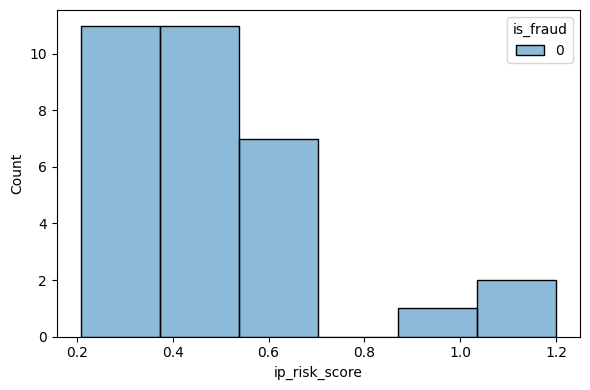

In [514]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.histplot(data = df.loc[(df.ip_country.isnull()) & (df.location_mismatch), ["ip_risk_score", "is_fraud"]], x = "ip_risk_score", hue = "is_fraud", ax = ax)

plt.tight_layout()
plt.show()

In [522]:
df.loc[(df.ip_country.isnull()) & (~df.location_mismatch), "ip_country"] = df.loc[(df.ip_country.isnull()) & (~df.location_mismatch), "home_country"]

In [528]:
df.loc[(df.ip_country.isnull()) & (df.location_mismatch), "ip_country"] = "unknown"

In [530]:
df.ip_country.value_counts()

ip_country
US         7110
UK         2492
CA         1764
unknown      34
Name: count, dtype: int64

In [532]:
df.groupby(by = ["ip_country"])["is_fraud"].mean().round(3)

ip_country
CA         0.172
UK         0.145
US         0.047
unknown    0.000
Name: is_fraud, dtype: float64

In [533]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                     303
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                      61
dtype: int64

In [534]:
df.kyc_tier.value_counts()

kyc_tier
standard    8138
enhanced    1875
low         1052
unknown       32
Name: count, dtype: int64

In [537]:
df.groupby(by = ["customer_id"]).aggregate({"kyc_tier": "nunique"}).kyc_tier.value_counts()

kyc_tier
1    1304
2      10
0       1
Name: count, dtype: int64

In [539]:
kyc_df = df.groupby(by = ["customer_id"], as_index = False).aggregate({"kyc_tier": "nunique"})
kyc_df.head()

,customer_id,kyc_tier
0,0006f893-10a8-4235-831b-fcae1e3f0140,1
1,00147b79-11ed-4f8f-a3af-651778b78dd3,1
2,00668d83-6f9f-4401-9a0f-04f94140abb6,1
3,00957a15-945f-4bfb-b5fc-d867cbaee95d,1
4,00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1


In [540]:
kyc_df.loc[kyc_df.kyc_tier == 0]

,customer_id,kyc_tier
562,691bb730-3142-40b3-a64f-0e54dc199252,0


In [541]:
df.loc[df.customer_id == "691bb730-3142-40b3-a64f-0e54dc199252"]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
536,46c8d157-c4fc-40f1-88a9-5039119f8d2e,691bb730-3142-40b3-a64f-0e54dc199252,2022-12-05 00:45:02.468549+00:00,UK,GBP,CNY,web,280.18,350.22,5.21,8.928571,9593519b-5581-40a2-a502-f17e3d790671,False,NaN,UK,False,0.342,NaN,208,NaN,0,0.294,0,0,0.0,0,2022-12-05 00:45:02.468549+00:00
4200,da3163c2-2f33-47e5-a721-9097791cbc11,691bb730-3142-40b3-a64f-0e54dc199252,2024-01-09 03:16:26.468549+00:00,UK,GBP,CAD,mobile,102.10,127.62,2.54,1.689189,9593519b-5581-40a2-a502-f17e3d790671,False,NaN,UK,False,0.206,NaN,208,NaN,0,0.294,0,0,0.0,0,2024-01-09 03:16:26.468549+00:00


In [544]:
df.loc[df.kyc_tier.isnull(), "ip_address"].isnull().mean()

np.float64(1.0)

In [545]:
df.loc[df.ip_address.isnull(), "kyc_tier"].isnull().mean()

np.float64(0.9934426229508196)

In [546]:
df.loc[(df.ip_address.isnull()) & (df.kyc_tier.notnull())]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
3185,71b2f122-f02e-45aa-9759-2f764f3474b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2023-09-23 19:03:22.468549+00:00,US,USD,INR,mobile,293.67,293.67,5.40,83.333333,fa5f773a-1074-49bc-b696-fb80eb85358f,False,NaN,US,False,0.333,unknown,367,NaN,0,0.176,0,0,0.00,0,2023-09-23 19:03:22.468549+00:00
4415,b6eba8f1-ff6c-48da-a553-e985e1f14909,7bd5200c-5d19-44f0-9afe-8b339a05366b,2024-01-30 11:33:12.468549+00:00,US,USD,NGN,web,1135.04,1135.04,17.98,1111.111111,01e74075-c3bd-455c-bd1f-71153b9a414c,False,NaN,US,False,0.316,unknown,147,NaN,0,0.391,0,0,0.25,0,2024-01-30 11:33:12.468549+00:00


In [550]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                     303
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                      61
dtype: int64

In [549]:
df.groupby(by = ["device_id"]).aggregate({"customer_id": "nunique"}).customer_id.unique()

array([1])

In [552]:
df.kyc_tier.isnull().sum()

np.int64(303)

In [551]:
df.kyc_tier.value_counts()

kyc_tier
standard    8138
enhanced    1875
low         1052
unknown       32
Name: count, dtype: int64

In [553]:
df.loc[df.device_trust_score.isnull(), "kyc_tier"].isnull().sum()

np.int64(293)

In [555]:
df.loc[(df.device_trust_score.isnull()) & (df.kyc_tier.notnull()), :]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
3185,71b2f122-f02e-45aa-9759-2f764f3474b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2023-09-23 19:03:22.468549+00:00,US,USD,INR,mobile,293.67,293.67,5.40,83.333333,fa5f773a-1074-49bc-b696-fb80eb85358f,False,NaN,US,False,0.333,unknown,367,NaN,0,0.176,0,0,0.00,0,2023-09-23 19:03:22.468549+00:00
4415,b6eba8f1-ff6c-48da-a553-e985e1f14909,7bd5200c-5d19-44f0-9afe-8b339a05366b,2024-01-30 11:33:12.468549+00:00,US,USD,NGN,web,1135.04,1135.04,17.98,1111.111111,01e74075-c3bd-455c-bd1f-71153b9a414c,False,NaN,US,False,0.316,unknown,147,NaN,0,0.391,0,0,0.25,0,2024-01-30 11:33:12.468549+00:00


In [556]:
df.loc[df.ip_address.isnull()].isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                      0
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                     303
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                       0
dtype: int64

In [326]:
dts.loc[dts.trust_score_count > 2]

trust_score_count
customer_id                          device_id                                              
140d2232-ee97-4934-81aa-9e5c323d7c6f 49fd6714-a356-498c-bfed-f9b90c616d9e                  3
                                     bee245a7-0c95-4ceb-bec2-fcd258bf5366                  3
                                     f88d5270-4bb5-4a23-b30a-1067eb941a69                  3
23d9943d-57b1-42eb-9ef2-05eed7fd1957 1f81d60c-25b5-495c-a49c-b59a3aa4fb3a                  3
                                     8ecdcffb-4c5e-4ff3-b499-abc221b139dc                  3
...                                                                                      ...
f7531a78-8bbe-4a85-b1e8-a0650edddc72 6fbeefc0-34c9-498e-a74c-8b53088c0a9e                  3
                                     c10d8360-5f7d-4a2d-bedc-8db83ed15441                  3
                                     c2155cfc-06a6-4053-a2ba-c0a4dc2bba1b                  3
                                     d7e2b666-f474-4232-b689-25a1a261cb60                  3
                                     ee7834df-5b50-4aa8-9cb4-61e32d89acdc                  3

[128 rows x 1 columns]

In [319]:
df.loc[df.device_trust_score < 0]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
51,37acea94-2ecf-4cba-bf3a-a2b418a02300,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-09 08:57:10.468549+00:00,US,USD,EUR,web,67.19,67.19,-1.00,0.925926,16e4b1b1-a590-45cf-b154-6b8edbcf0dbd,False,71.133.231.78,CA,True,1.2,standard,263,-0.1,0,0.223,-1,0,0.00,0,2022-10-09 08:57:10.468549+00:00
60,c42328f0-a715-472d-b261-61edc7ae5dd0,d71c91b4-fee8-4104-9856-a5c6109a62e3,2022-10-10 12:06:38.468549+00:00,US,USD,USD,mobile,190.42,190.42,-1.00,1.000000,bad152b7-36e0-4613-820d-bec469406d0c,False,102.188.190.205,US,False,1.2,standard,298,-0.1,0,0.166,-1,0,0.00,0,2022-10-10 12:06:38.468549+00:00
78,1b5ca03f-8c61-47fc-9005-69f9f6e80641,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-12 08:33:52.468549+00:00,US,USD,INR,web,130.13,130.13,-1.00,83.333333,1116845f-d9e9-4194-bf8c-9ab64d4dcaf8,False,154.171.88.114,US,False,1.2,enhanced,257,-0.1,0,0.257,-1,0,0.00,0,2022-10-12 08:33:52.468549+00:00
225,d62b3fb6-ed94-45ca-9024-2fe6ecf85ff1,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-28 19:29:13.468549+00:00,US,USD,GBP,ATM,81.19,81.19,-1.00,0.800000,0fb34cef-8f16-4c2f-97b4-acff71c1e81a,False,51.190.9.19,US,False,1.2,standard,147,-0.1,0,0.391,-1,1,0.00,0,2022-10-28 19:29:13.468549+00:00
328,3bcab4c7-dc2e-416c-b57e-266aafe46a47,d71c91b4-fee8-4104-9856-a5c6109a62e3,2022-11-10 03:14:05.468549+00:00,US,USD,NGN,mobile,37.08,37.08,9999.99,1111.111111,71160c48-db1a-4f33-b137-68d7f44ccd98,False,223.51.189.238,US,False,1.2,standard,298,-0.1,0,0.166,-1,0,0.25,0,2022-11-10 03:14:05.468549+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9982,bac7754a-4335-4d89-8ca6-f6530377c936,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-09-30 21:52:28.468549+00:00,US,USD,INR,mobile,164.16,164.16,-1.00,83.333333,ecf86eb0-ca14-4e1c-905c-3134d0a3a647,False,195.144.215.27,US,False,1.2,standard,298,-0.1,0,0.166,-1,0,0.00,0,2025-09-30 21:52:28.468549+00:00
10001,88dd45c3-38b9-498f-a767-0fc20c598a89,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2023-08-29 10:22:29.468549+00:00,US,USD,GBP,mobile,320.40,320.40,9999.99,0.800000,06029fc9-380f-4b08-a9a4-506f1b4249fb,False,214.69.54.29,US,False,1.2,standard,1018,-0.1,0,0.087,-1,0,0.00,0,2023-08-29 10:22:29.468549+00:00
10006,42f2b1e2-4983-40c7-9b48-c8c6b10dd847,140d2232-ee97-4934-81aa-9e5c323d7c6f,2024-09-14 09:31:14.468549+00:00,CA,CAD,EUR,ATM,272.59,201.72,9999.99,0.685185,9849347e-5774-4f24-ac70-de0c98536adf,False,86.94.79.160,CA,False,1.2,low,824,-0.1,0,0.282,-1,0,0.00,0,2024-09-14 09:31:14.468549+00:00
10131,c4b50fee-3c02-4aa0-bcb4-321c24ed415e,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2024-02-07 07:06:42.468549+00:00,UK,GBP,INR,mobile,161.80,202.25,-1.00,104.166667,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,74.138.217.202,UK,False,1.2,standard,4,-0.1,0,0.407,-1,0,0.00,0,2024-02-07 07:06:42.468549+00:00


In [312]:
df.loc[df.device_trust_score.isnull()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
13,1a34a095-3be4-4a69-a22e-803be566526c,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-10-05 07:04:39.468549+00:00,UK,GBP,EUR,mobile,322.24,402.80,5.84,1.157407,9957de24-ace9-4938-bb81-6e7e41276961,False,NaN,NaN,False,0.245,NaN,4,NaN,0,0.407,0,0,0.05,0,2022-10-05 07:04:39.468549+00:00
49,b489474c-b729-4759-86e9-51778ddea385,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-08 20:45:48.468549+00:00,US,USD,INR,mobile,255.06,255.06,4.82,83.333333,b823bda8-e2a3-4541-a8d3-ae59fc963dd7,False,NaN,NaN,False,0.530,NaN,263,NaN,0,0.223,0,0,0.00,0,2022-10-08 20:45:48.468549+00:00
151,32cbd613-5c6c-4797-be15-165bc408c2ca,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-20 22:08:59.468549+00:00,US,USD,MXN,mobile,502.97,502.97,8.53,17.241379,8d9e4e31-6e23-4e66-904f-4eb99949ef18,False,NaN,NaN,False,0.310,NaN,1018,NaN,0,0.087,0,0,0.20,0,2022-10-20 22:08:59.468549+00:00
163,8b339135-7446-4689-9bd2-0509f23903f0,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-22 01:51:23.468549+00:00,CA,CAD,USD,web,100.87,74.72,2.51,0.740000,8019e57a-9457-48a4-9dfb-ec9b4981c5c5,False,NaN,NaN,False,0.519,NaN,947,NaN,0,0.268,7,7,0.00,0,2022-10-22 01:51:23.468549+00:00
168,c6c7f296-be97-4d18-a93e-719fcba43dce,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-22 10:08:19.468549+00:00,US,USD,MXN,mobile,265.30,265.30,4.98,17.241379,446cf778-9e03-47ef-bb1f-1f1c2318c250,False,NaN,NaN,True,0.655,NaN,367,NaN,0,0.176,0,0,0.20,0,2022-10-22 10:08:19.468549+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10054,35da0a3e-5776-4f7e-b102-5ea3d5034713,402cccc9-28de-45b3-9af7-cc5302aa1f93,2025-06-20 07:38:53.468549+00:00,US,USD,EUR,mobile,9993.94,9993.94,150.44,0.925926,b3290ccd-926f-4e98-b219-eab283ad718a,False,NaN,NaN,False,0.434,NaN,263,NaN,0,0.223,0,0,0.00,0,2025-06-20 07:38:53.468549+00:00
10082,adc74103-d3b7-491e-a3c9-02aae2050d46,7bd5200c-5d19-44f0-9afe-8b339a05366b,2025-01-27 17:14:38.468549+00:00,US,USD,USD,mobile,414.29,414.29,7.20,1.000000,eb8cac8c-da67-4a9a-84c9-e67242be9cbd,False,NaN,NaN,False,0.446,NaN,147,NaN,0,0.391,0,0,0.00,1,2025-01-27 17:14:38.468549+00:00
10093,d5ce08b7-d78f-4e1b-97c0-362cc64e12ee,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2024-06-28 06:10:20.468549+00:00,US,USD,PHP,mobile,125.75,125.75,2.89,58.823529,991bd49b-7d62-4ac6-81bf-b2e16aa7c0f2,False,NaN,NaN,False,0.451,NaN,1018,NaN,0,0.087,0,0,0.10,0,2024-06-28 06:10:20.468549+00:00
10142,356a1a21-e76c-4ad6-b712-405d3ad215e6,23d9943d-57b1-42eb-9ef2-05eed7fd1957,2024-03-04 21:11:40.468549+00:00,UK,GBP,INR,mobile,83.96,104.95,2.27,104.166667,1bbcba69-0f10-499b-9d26-3d9b59cc3dfc,False,NaN,NaN,False,0.474,NaN,718,NaN,0,0.169,0,0,0.00,0,2024-03-04 21:11:40.468549+00:00


In [217]:
idx = y[y <= -1.452799].index

In [220]:
fee_df.loc[idx]

,fee,amount_usd,source_currency
47,-1.0,67.19,USD
55,-1.0,190.42,USD
73,-1.0,130.13,USD
210,-1.0,81.19,USD
325,-1.0,316.74,USD
...,...,...,...
9271,-1.0,156.30,USD
9277,-1.0,284.58,USD
9379,-1.0,215.44,GBP
9388,-1.0,164.16,USD


In [219]:
fee_df.loc[idx, "fee"].value_counts()

fee
-1.0    98
Name: count, dtype: int64

In [142]:
y_hat

0       -0.000538
1        0.001106
2        0.001026
3        0.002366
4        0.000487
           ...   
10785   -0.000446
10786   -0.002122
10787    0.001139
10788    0.002119
10789   -0.012961
Name: amount_usd, Length: 10790, dtype: float64

In [125]:
df.loc[df.amount_usd > max_, "amount_usd"]

11       9998.43
15       9991.85
53       7398.00
88       9993.40
147      7395.25
          ...   
11323    2468.29
11334    4112.77
11342    6053.90
11365    9237.34
11374    3503.36
Name: amount_usd, Length: 288, dtype: float64

In [116]:
df.loc[df.fee.isnull(), "amount_usd"].quantile(0.25)

np.float64(86.715)

In [105]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   304
location_mismatch              0
ip_risk_score                  0
kyc_tier                     303
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                      61
dtype: int64

In [8]:
df.loc[df.timestamp.isnull(), :]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
158,e6ef7b85-c19f-43fa-befa-743e37c62583,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,PHP,mobile,248.92,248.92,5.56,...,0.197,enhanced,367,0.939,0,0.176,0,0,0.10,0
160,2b64ca36-f140-4de4-9cc8-c678255402a9,d71c91b4-fee8-4104-9856-a5c6109a62e3,NaN,US,USD,CNY,web,75.44,75.44,1.31,...,0.353,standard,298,0.336,0,0.166,0,0,0.00,0
578,b371fb34-0744-4b90-b33d-237b95b0cd52,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,INR,mobile,251.95,251.95,5.68,...,0.424,enhanced,367,0.939,0,0.176,0,0,0.00,0
1003,3e96cacd-3722-469f-95c1-6dce5ba73aa6,7bd5200c-5d19-44f0-9afe-8b339a05366b,NaN,US,USD,GBP,web,51.22,51.22,1.23,...,0.569,standard,147,0.401,0,0.391,0,1,0.00,0
1325,c646535b-dd51-4d09-b155-e603bbafdc7e,70a93d26-8e3a-4179-900c-a4a7a74d08e5,NaN,US,USD,USD,mobile,9993.44,9993.44,150.77,...,0.398,enhanced,257,0.894,0,0.257,0,1,0.00,0
1501,f340c84f-8021-483c-9a7e-b1fae29a3859,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,GBP,web,165.8,165.80,3.62,...,0.337,enhanced,367,0.939,0,0.176,0,0,0.00,0
1522,fcf3662d-6acd-4303-902f-0a46cefda734,7bd5200c-5d19-44f0-9afe-8b339a05366b,NaN,US,USD,GBP,mobile,90.11,90.11,2.42,...,0.268,standard,147,0.551,0,0.391,0,0,0.00,0
1780,c99dc8d7-24b9-4527-93dc-29cb6711bbe6,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,NaN,UK,GBP,PHP,web,41.1,51.37,2.13,...,0.234,standard,4,0.892,0,0.407,0,0,0.00,1
2053,bf335e6c-a6bc-4fa3-96ed-516d8d7ca793,af8ca4c4-8703-4c55-b66c-2b76cd70040d,NaN,US,USD,PHP,mobile,126.75,126.75,3.55,...,0.257,standard,1018,0.934,0,0.087,0,0,0.10,0
2112,611e6035-5389-45bd-a467-6aaf83493a0a,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,INR,mobile,56.95,56.95,1.78,...,0.304,standard,263,0.522,0,0.223,0,1,0.00,0


In [11]:
df.source_currency.value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [12]:
df.dest_currency.value_counts()

dest_currency
NGN    1474
USD    1328
INR    1325
CNY    1324
PHP    1314
GBP    1296
CAD    1282
EUR    1196
MXN     861
Name: count, dtype: int64

In [14]:
df.loc[(df.source_currency == "USD") & (df.dest_currency == "USD"), :].head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11,43a11314-6420-4e23-b0a8-69d5f010da86,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-04 22:54:28.468549+00:00,US,USD,USD,mobile,9998.43,9998.43,151.63,1.0,4bb9533a-117f-455a-9e69-a484a77a7176,False,79.129.58.248,US,False,0.254,standard,1018,0.934,0,0.087,0,0,0.0,0
25,8b701ec2-f0d3-432d-bb4b-7e1745bef34f,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-06 09:34:57.468549+00:00,US,USD,USD,mobile,121.06,121.06,3.04,1.0,162dcfa8-d2e4-4449-9b0d-7d56fd981991,False,155.92.229.247,US,False,0.163,standard,147,0.551,0,0.391,0,0,0.0,0
32,1823877a-cc28-4333-929a-5523a0d20120,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-07 08:31:21.468549+00:00,US,USD,USD,mobile,232.66,232.66,4.31,1.0,33919fa4-5dbb-41b0-a895-ec15ab2c10f1,False,62.78.115.149,US,False,0.271,standard,263,0.522,0,0.223,0,0,0.0,0
34,8fe20fa1-61c3-4eae-a3ed-160718e0b209,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-07 09:07:42.468549+00:00,US,USD,USD,mobile,61.27,61.27,1.79,1.0,3deb41ac-8c17-4c96-b1e9-24c67ea0de90,False,218.149.36.208,US,False,0.223,enhanced,367,0.939,0,0.176,0,0,0.0,0
44,f38d1c57-3dd4-433e-a3cd-c07f4ec25304,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-08 08:19:24.468549+00:00,US,USD,USD,web,254.28,254.28,4.22,1.0,ff15b1b0-c6a7-4bd1-8ba7-a892d37c8d02,True,56.105.104.32,US,False,0.378,standard,1018,0.784,0,0.087,0,0,0.0,0
